1. Importar librerías y conectar a la Base de Datos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Conexión a PostgreSQL
load_dotenv('../.env') # Subimos un nivel porque estamos dentro de /notebooks
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

engine = create_engine(f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")
print("Conectado a PostgreSQL para análisis.")

C:\Users\Andres\AppData\Local\Temp\ipykernel_20844\3637284326.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Conectado a PostgreSQL para análisis.


2. Extraer los datos mediante SQL para analizarlos en Pandas

In [2]:
query = """
SELECT 
    v.id_venta,
    v.fecha,
    v.cantidad,
    v.estado,
    p.nombre_producto,
    p.precio_unitario,
    (v.cantidad * p.precio_unitario) as total_venta,
    c.categoria,
    cl.region,
    m.metodo
FROM ventas v
JOIN productos p ON v.id_producto = p.id_producto
JOIN categorias c ON p.id_categoria = c.id_categoria
JOIN clientes cl ON v.id_cliente = cl.id_cliente
JOIN metodos_pago m ON v.id_metodo = m.id_metodo
WHERE v.estado = 'Completa';
"""

# Cargar a un DataFrame
df_ventas = pd.read_sql(query, engine)
df_ventas['fecha'] = pd.to_datetime(df_ventas['fecha'])

# Mostrar las primeras 5 filas
df_ventas.head()

,id_venta,fecha,cantidad,estado,nombre_producto,precio_unitario,total_venta,categoria,region,metodo
0,919,2024-01-31,5,Completa,Pizza congelada,15.45,77.25,Congelados,Buenos Aires,Efectivo
1,947,2024-01-31,1,Completa,Manteca,5.65,5.65,Lácteos,NEA,Mercado Pago
2,1317,2024-01-31,3,Completa,Pizza congelada,15.45,46.35,Congelados,NEA,Tarjeta de Débito
3,1607,2024-01-31,5,Completa,Medialunas,3.51,17.55,Panadería,Centro,Efectivo
4,2038,2024-01-31,5,Completa,Yogur,5.21,26.05,Lácteos,Buenos Aires,Mercado Pago


3. Visión General del Dataset

In [3]:
print(f"Total de registros de ventas completadas: {df_ventas.shape[0]}")
print(f"Columnas disponibles: {df_ventas.shape[1]}\n")

print("--- Resumen Estadístico ---")
display(df_ventas[['cantidad', 'precio_unitario', 'total_venta']].describe())

Total de registros de ventas completadas: 2523
Columnas disponibles: 10

--- Resumen Estadístico ---


,cantidad,precio_unitario,total_venta
count,2523.000000,2523.000000,2523.000000
mean,3.501387,9.896849,34.772053
std,1.710251,5.543499,27.897901
min,1.000000,3.250000,3.250000
25%,2.000000,5.450000,14.600000
50%,4.000000,8.540000,26.160000
75%,5.000000,13.540000,47.250000
max,6.000000,28.560000,171.360000


Pregunta de Negocio 1 - ¿Cuáles son las categorías que más dinero generan?

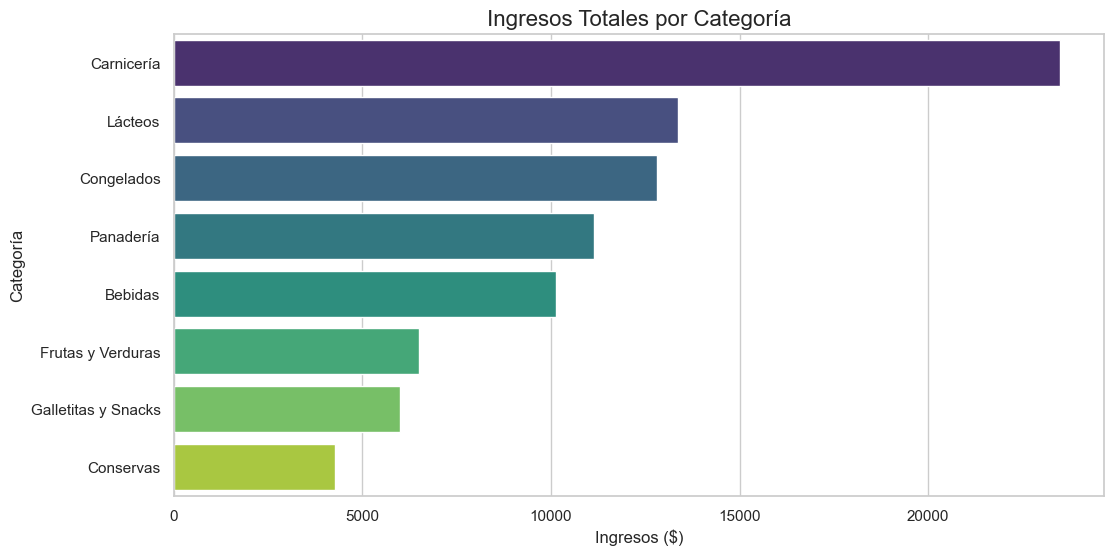

In [5]:
ventas_por_categoria = df_ventas.groupby('categoria')['total_venta'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
# Agregamos hue y legend=False exactamente como nos pidió la advertencia
sns.barplot(
    x=ventas_por_categoria.values, 
    y=ventas_por_categoria.index, 
    hue=ventas_por_categoria.index,
    palette="viridis",
    legend=False
)
plt.title('Ingresos Totales por Categoría', fontsize=16)
plt.xlabel('Ingresos ($)', fontsize=12)
plt.ylabel('Categoría', fontsize=12)
plt.show()

Pregunta de Negocio 2 - ¿Cuál es la preferencia de Métodos de Pago?

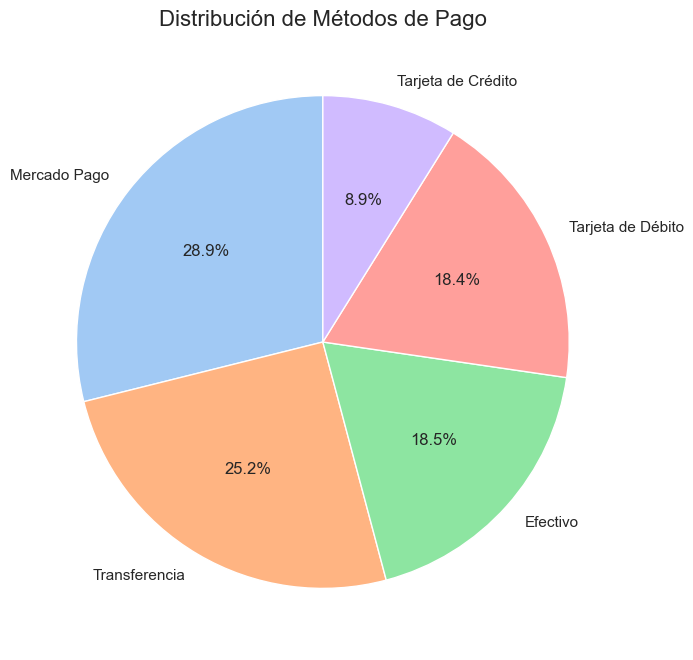

In [6]:
metodos_pago = df_ventas['metodo'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(metodos_pago.values, labels=metodos_pago.index, autopct='%1.1f%%', 
        colors=sns.color_palette("pastel"), startangle=90)
plt.title('Distribución de Métodos de Pago', fontsize=16)
plt.show()